# Análise de Risco de Crédito: Previsão de Inadimplência

Este notebook tem como objetivo realizar uma análise exploratória de dados para entender os fatores que contribuem para a inadimplência de clientes em uma base de dados de cartões de crédito. Serão investigadas variáveis demográficas, financeiras e de comportamento de pagamento para identificar padrões e insights.

## 1. Configuração e Carregamento de Dados

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount('/content/drive')

# Carrega os dados do arquivo Excel
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/UCI_Credit_Card1.xlsx')

# Define um estilo de plotagem padrão
plt.style.use('/content/drive/MyDrive/Colab Notebooks/meu_estilo.mplstyle');

Mounted at /content/drive


### 1.1 Visão Geral dos Dados

In [2]:
# Exibe as primeiras 5 linhas do DataFrame para entender sua estrutura
display(df.head())

# Exibe informações sobre o DataFrame, incluindo tipos de dados e valores não nulos
df.info()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

## 2. Análise da Variável Alvo: Default Payment (Próximo Mês)

A variável `default.payment.next.month` indica se o cliente irá entrar em inadimplência no próximo mês (1 = sim, 0 = não). É crucial entender a distribuição dessa variável para avaliar o desbalanceamento da classe.

In [3]:
# Calcula a proporção de clientes adimplentes e inadimplentes
default_counts = df['default.payment.next.month'].value_counts(normalize=True) * 100
display(default_counts)

# Mapeia os valores numéricos para rótulos mais descritivos
default_label = {
    0: 'Não Inadimplente',
    1: 'Inadimplente'
}

default_mapped = df['default.payment.next.month'].map(default_label)
mapped_default_counts = default_mapped.value_counts(normalize=True) * 100
display(mapped_default_counts)

,proportion
default.payment.next.month,
0,77.88
1,22.12


,proportion
default.payment.next.month,
Não Inadimplente,77.88
Inadimplente,22.12


### 2.1 Visualização da Proporção de Inadimplência

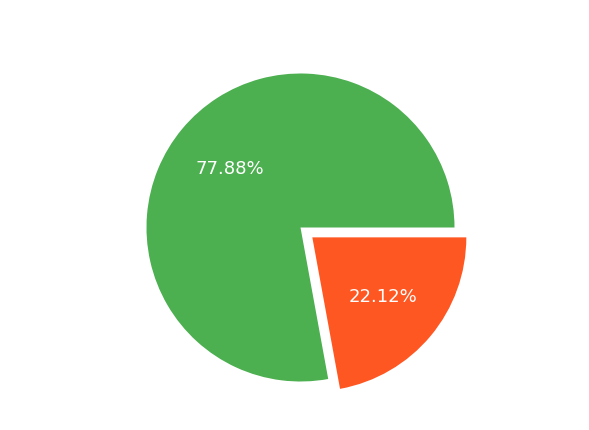

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

plt.pie(mapped_default_counts, labels=mapped_default_counts.index, autopct='%1.2f%%', explode=[0, 0.1], colors=['#4CAF50', '#FF5722'])
plt.title('Proporção de Inadimplência vs. Adimplência', fontsize=16, fontweight='bold')

plt.savefig('default_ratio.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

#### Análise:
É visível que a base de dados possui um desbalanceamento considerável, com aproximadamente 77.88% dos clientes sendo adimplentes e 22.12% inadimplentes. Essa proporção é importante para considerar em futuras análises e na construção de modelos preditivos, onde técnicas para lidar com classes desbalanceadas podem ser necessárias.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/UCI_Credit_Card1.xlsx')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [6]:
df['default.payment.next.month'].value_counts(normalize=True)*100

,proportion
default.payment.next.month,
0,77.88
1,22.12


In [7]:
default_label = {
    0: 'No Default',
    1: 'Default'
}

In [8]:
default = df['default.payment.next.month'].map(default_label)
default.value_counts(normalize=True)*100

,proportion
default.payment.next.month,
No Default,77.88
Default,22.12


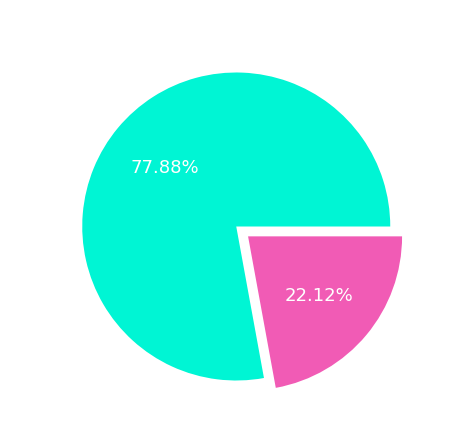

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

plt.pie(default.value_counts(), labels=default.value_counts().index, autopct='%1.2f%%', explode=[0, 0.1])
plt.title('Proportion of Default vs Non-Default')

plt.savefig('default_ratio.png', transparent=True, bbox_inches='tight', dpi=300)

plt.show()

Em uma primeira análise podemos perceber que menos de 1/4 dos clientes dessa base de dados são inadimplentes. Precisamos analisar o que esses 22% apresentam em comum para prever default e a partir disso, dar um score de crédito adequado para cada pessoa para que o banco possa conceder crédito de maneira mais acertiva para cada pessoa e evitar prejuízos.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [11]:
# drive.mount('/content/drive')
# plt.style.use('/content/drive/MyDrive/Colab Notebooks/meu_estilo.mplstyle');
plt.style.use('default')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# **Análise de sexo**



In [12]:
sex_labels = {
    1: 'Male',
    2: 'Female'
}

#df['SEX'] = df['SEX'].map(sex_labels)

In [13]:
default_sex = df.groupby('SEX')['default.payment.next.month'].mean().round(4) * 100
default_sex = default_sex.groupby(default_sex.index.map(sex_labels)).mean().sort_values(ascending=False)
display(default_sex)

,default.payment.next.month
SEX,
Male,24.17
Female,20.78


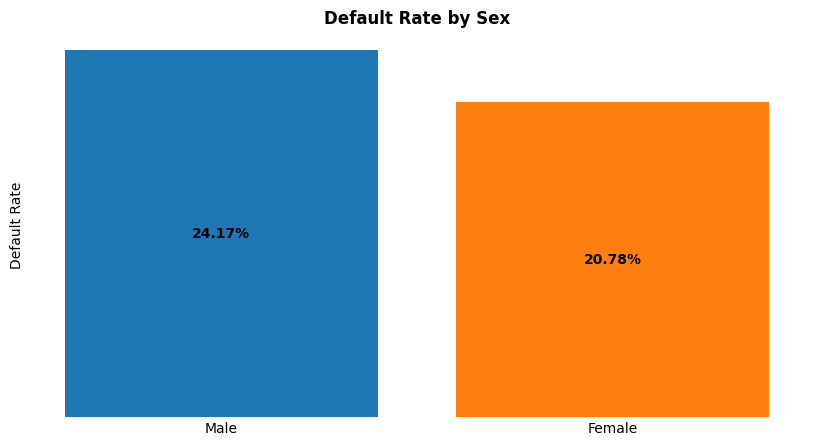

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(default_sex.index, default_sex.values, color=plt.rcParams['axes.prop_cycle'].by_key()['color'])
plt.ylabel('Default Rate')
plt.title('Default Rate by Sex', fontweight='bold')
plt.bar_label(ax.containers[0], fmt='%.2f%%', label_type='center', fontweight='bold')
plt.tick_params(axis='x', length=0)
plt.yticks([])
plt.box(False)
plt.grid(False)

plt.savefig('default_by_sex.png', transparent=True, bbox_inches='tight', dpi=300)

plt.show()

Default por sexo:
homens tendem a ser ligeiramente mais inadinplentes que as mulhres

# **Análise de escolaridade**

In [15]:
education_labels = {
    0: 'Unknown',
    1: 'Graduate School',
    2: 'University',
    3: 'High School',
    4: 'Others',
    5: 'Unknown',
    6: 'Unknown'
}

df['EDUCATION'] = df['EDUCATION'].map(education_labels)

In [16]:
default_education = df.groupby('EDUCATION')['default.payment.next.month'].mean().sort_values(ascending=False).round(4) * 100
display(default_education)

,default.payment.next.month
EDUCATION,
High School,25.16
University,23.73
Graduate School,19.23
Unknown,7.54
Others,5.69


In [17]:
from matplotlib.colors import Normalize
default_education = df.groupby('EDUCATION')['default.payment.next.month'].count().sort_values(ascending=False)
display(default_education)

,default.payment.next.month
EDUCATION,
University,14030
Graduate School,10585
High School,4917
Unknown,345
Others,123


Others: não está muito bem especificado o que é e representa menos de 0.5% da base de dados, então não é coerente usarmos essa classificação como mínimo. Poderia acabar dando muito peso a algo por uma pequena parcela da base de dados ser muito fora da curva e além disso, não está bem definido essa classificação.
Além disso, por incapacidade de identificação do grau de escolaridade durante o preenchimento do formulário ou por 'deixar em branco' outras 345 pessoas estão com classificação desconhecida e puxando os dados muito para baixo. Como repreentam cerca de 1% da base de dados atmbém não serão considerados.
Mas podemos perceber que a inadimplência cai com o aumento da escolaridade.

In [18]:
df_filter_education = df[~df['EDUCATION'].isin(['Unknown', 'Others'])]
df_filter_education.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29532 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   ID                          29532 non-null  int64 
 1   LIMIT_BAL                   29532 non-null  int64 
 2   SEX                         29532 non-null  int64 
 3   EDUCATION                   29532 non-null  object
 4   MARRIAGE                    29532 non-null  int64 
 5   AGE                         29532 non-null  int64 
 6   PAY_0                       29532 non-null  int64 
 7   PAY_2                       29532 non-null  int64 
 8   PAY_3                       29532 non-null  int64 
 9   PAY_4                       29532 non-null  int64 
 10  PAY_5                       29532 non-null  int64 
 11  PAY_6                       29532 non-null  int64 
 12  BILL_AMT1                   29532 non-null  int64 
 13  BILL_AMT2                   29532 non-null  int64 


In [19]:
default_education = df_filter_education.groupby('EDUCATION')['default.payment.next.month'].mean().sort_values(ascending=False).round(4) * 100
display(default_education)

,default.payment.next.month
EDUCATION,
High School,25.16
University,23.73
Graduate School,19.23


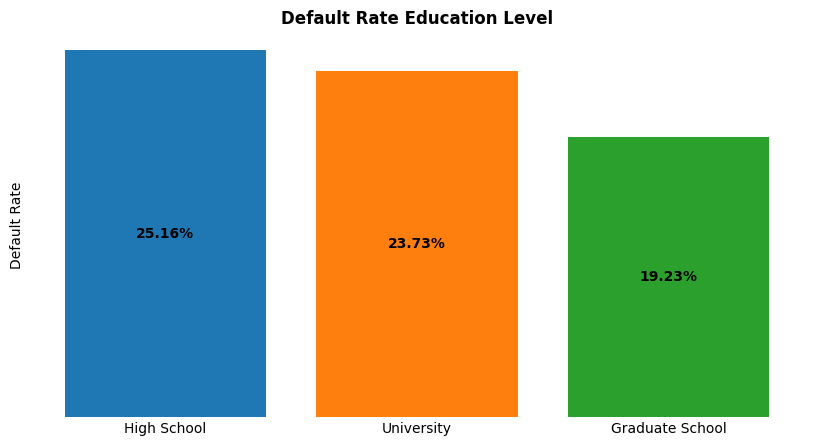

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(default_education.index, default_education.values, color=plt.rcParams['axes.prop_cycle'].by_key()['color'])

plt.ylabel('Default Rate')
plt.title('Default Rate Education Level', fontweight='bold')

plt.bar_label(ax.containers[0], fmt='%.2f%%', label_type='center', fontweight='bold')

plt.tick_params(axis='x', length=0)
plt.yticks([])
plt.box(False)
plt.grid(False)

plt.savefig('default_by_age_group.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

# **Análise de idade**

In [21]:
new_age_bins = [18, 26, 36, 51, 100]
new_age_labels = ['18-25', '26-35', '36-50', '51+']

In [22]:
df['AGE_GROUP'] = pd.cut(df['AGE'], bins=new_age_bins, labels=new_age_labels, right=False)

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,AGE_GROUP
0,1,20000,2,University,1,24,2,2,-1,-1,...,0,0,0,689,0,0,0,0,1,18-25
1,2,120000,2,University,2,26,-1,2,0,0,...,3455,3261,0,1000,1000,1000,0,2000,1,26-35
2,3,90000,2,University,2,34,0,0,0,0,...,14948,15549,1518,1500,1000,1000,1000,5000,0,26-35
3,4,50000,2,University,1,37,0,0,0,0,...,28959,29547,2000,2019,1200,1100,1069,1000,0,36-50
4,5,50000,1,University,1,57,-1,0,-1,0,...,19146,19131,2000,36681,10000,9000,689,679,0,51+


In [23]:
default_by_new_age_group = df.groupby('AGE_GROUP', observed=False)['default.payment.next.month'].mean().round(4) * 100
display(default_by_new_age_group)

,default.payment.next.month
AGE_GROUP,
18-25,26.66
26-35,19.83
36-50,22.54
51+,25.43


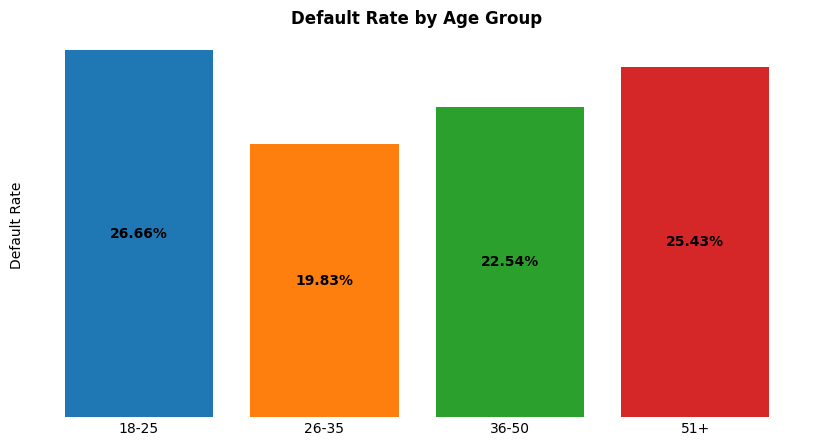

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(default_by_new_age_group.index, default_by_new_age_group.values, color=plt.rcParams['axes.prop_cycle'].by_key()['color'])

plt.ylabel('Default Rate')
plt.title('Default Rate by Age Group', fontweight='bold')

plt.bar_label(ax.containers[0], fmt='%.2f%%', label_type='center', fontweight='bold')

plt.tick_params(axis='x', length=0)
plt.yticks([])
plt.box(False)
plt.grid(False)

plt.savefig('default_by_age_group.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

O início da vida financeira tende a gerar mais inadimlência, o que vai diminuindo e aumenta posteriormente, um comportamento parabólico

# **Análise estado civil**

In [25]:
marriage_labels = {
    0: 'Unknown',
    1: 'Married',
    2: 'Single',
    3: 'Others'
}

In [26]:
default_marriage = df.groupby('MARRIAGE')['default.payment.next.month'].mean().round(4) * 100
default_marriage = default_marriage.groupby(default_marriage.index.map(marriage_labels)).mean().sort_values(ascending=False)
display(default_marriage)

,default.payment.next.month
MARRIAGE,
Others,26.01
Married,23.47
Single,20.93
Unknown,9.26


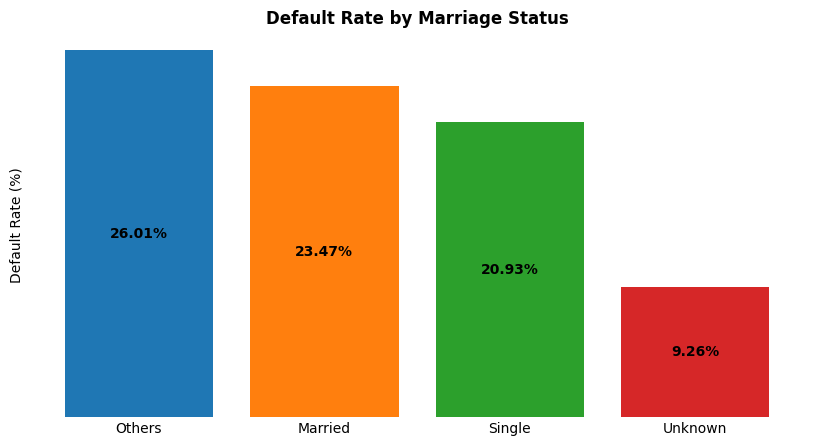

In [27]:
fig, ax = plt.subplots(figsize=(10,5))

ax.bar(default_marriage.index, default_marriage.values, color=plt.rcParams['axes.prop_cycle'].by_key()['color'])
plt.xticks(ticks=default_marriage.index);
plt.ylabel('Default Rate (%)')
plt.title('Default Rate by Marriage Status', fontweight='bold')
plt.bar_label(ax.containers[0], fmt='%.2f%%', label_type='center', fontweight='bold')
plt.tick_params(axis='x', length=0)
plt.yticks([])
plt.box(False)
plt.grid(False)

plt.savefig('default_by_marriage.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()


In [28]:
default_marriage = df.groupby('MARRIAGE')['default.payment.next.month'].count()
default_marriage = default_marriage.groupby(default_marriage.index.map(marriage_labels)).mean().sort_values(ascending=False)
display(default_marriage)

,default.payment.next.month
MARRIAGE,
Single,15964.0
Married,13659.0
Others,323.0
Unknown,54.0


Como pode ser visto, existem apenas 54 pessoas estão sem classificação, o que representa apenas 0.18% da base de dados. Portanto o mais sensato a sefazer é remover essa classificação para analisar melhor a variável MARRIAGE.

In [29]:
df_filter_marriage = df[df['MARRIAGE'] != 0]


In [30]:
default_marriage_filtered = df_filter_marriage.groupby('MARRIAGE')['default.payment.next.month'].mean().round(4) * 100
default_marriage_filtered = default_marriage_filtered.groupby(default_marriage_filtered.index.map(marriage_labels)).mean().sort_values(ascending=False)
display(default_marriage_filtered)

,default.payment.next.month
MARRIAGE,
Others,26.01
Married,23.47
Single,20.93


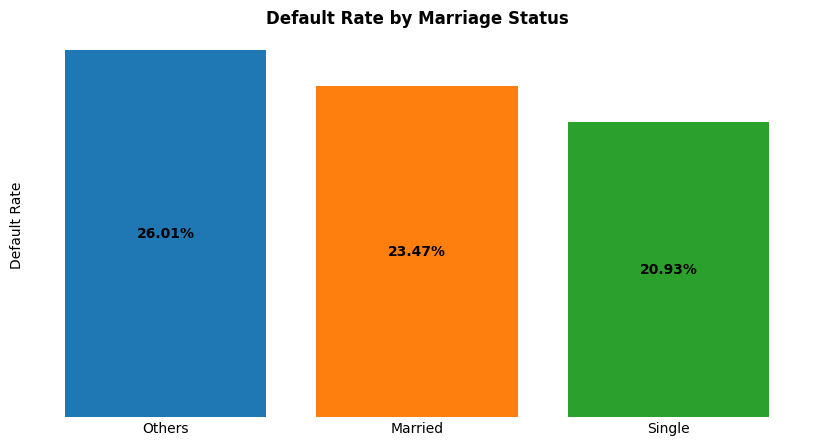

In [31]:
fig, ax = plt.subplots(figsize=(10,5))

ax.bar(default_marriage_filtered.index, default_marriage_filtered.values, color=plt.rcParams['axes.prop_cycle'].by_key()['color'])
plt.ylabel('Default Rate')
plt.title('Default Rate by Marriage Status', fontweight='bold')
plt.bar_label(ax.containers[0], fmt='%.2f%%', label_type='center', fontweight='bold')
plt.tick_params(axis='x', length=0)
plt.yticks([])
plt.box(False)
plt.grid(False)

plt.savefig('default_by_marriage_filtered.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

solteiros são ligeiramente menos inadimplentes que casados, quem não se encaixa nesses dois casos tende a ser mais inadimplente.

---
# **Rusumo das varáveis demográficas**
---

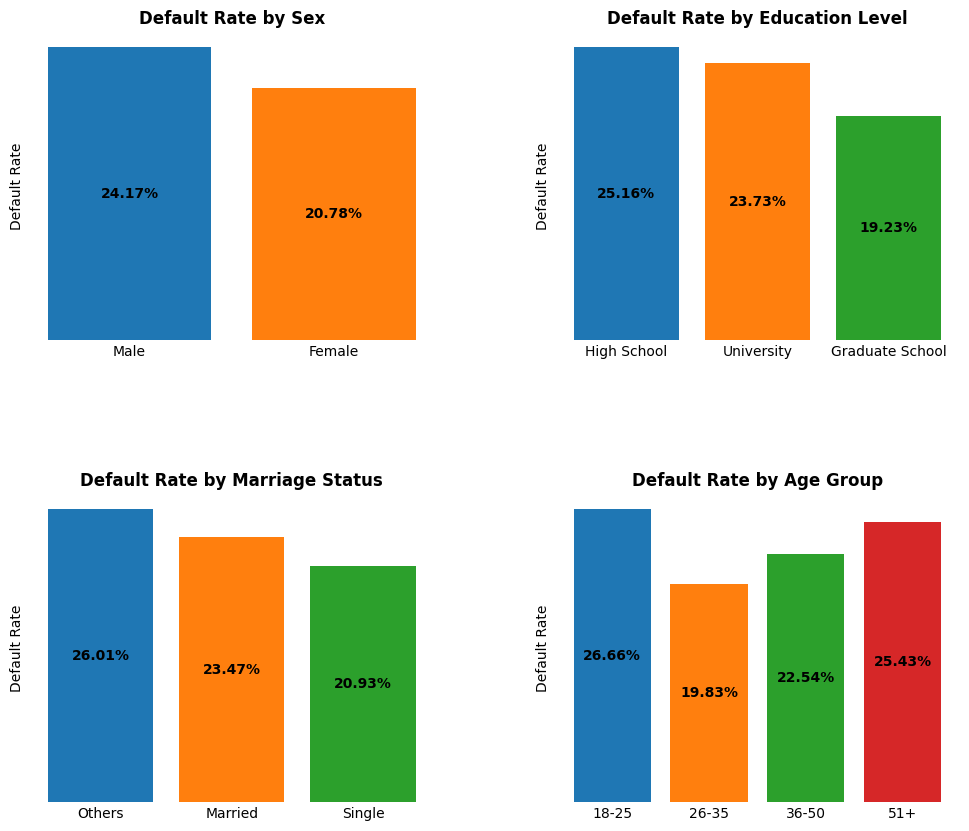

In [32]:
def plot_default_rate_bar(ax, data, title, ylabel='Default Rate'):
    ax.bar(data.index, data.values, color=plt.rcParams['axes.prop_cycle'].by_key()['color'])
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.bar_label(ax.containers[0], fmt='%.2f%%', label_type='center', fontweight='bold')
    ax.tick_params(axis='x', length=0)
    ax.set_yticks([])

mosaico = 'AB;CD'
fig = plt.figure(figsize=(12, 10))
axs = fig.subplot_mosaic(mosaico)

#gráfico 1
plot_default_rate_bar(axs['A'], default_sex, 'Default Rate by Sex')

#gráfico 2
plot_default_rate_bar(axs['B'], default_education, 'Default Rate by Education Level')

#gráfico 3
plot_default_rate_bar(axs['C'], default_marriage_filtered, 'Default Rate by Marriage Status')

#gráfico 4
plot_default_rate_bar(axs['D'], default_by_new_age_group, 'Default Rate by Age Group')

#Ajustes finais
# fig.suptitle('Demographic Variables', fontsize=20, fontweight='bold')
fig.subplots_adjust(hspace=0.5, wspace=0.3)

for ax_key in axs:
    for spine in axs[ax_key].spines.values():
        spine.set_visible(False)
    axs[ax_key].grid(False)

plt.savefig('demographic_variables.png', transparent=True, bbox_inches='tight', dpi=300)

plt.show()

# **Análise do  limite do cartão (LIMIT_BAL)**

In [33]:
new_limit_bins = [0, 50_001, 100_001, 200_001, 300_001, 100_000_000_000_000_000]
new_limit_labels = ['Up to 50k', '50k-100k', '100k-200k', '200k-300k', '300k+']

df['LIMIT_GROUP'] = pd.cut(df['LIMIT_BAL'], bins=new_limit_bins, labels=new_limit_labels, right=False)
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,AGE_GROUP,LIMIT_GROUP
0,1,20000,2,University,1,24,2,2,-1,-1,...,0,0,689,0,0,0,0,1,18-25,Up to 50k
1,2,120000,2,University,2,26,-1,2,0,0,...,3261,0,1000,1000,1000,0,2000,1,26-35,100k-200k
2,3,90000,2,University,2,34,0,0,0,0,...,15549,1518,1500,1000,1000,1000,5000,0,26-35,50k-100k
3,4,50000,2,University,1,37,0,0,0,0,...,29547,2000,2019,1200,1100,1069,1000,0,36-50,Up to 50k
4,5,50000,1,University,1,57,-1,0,-1,0,...,19131,2000,36681,10000,9000,689,679,0,51+,Up to 50k


In [34]:
default_limit = df.groupby('LIMIT_GROUP')['default.payment.next.month'].mean().round(4) * 100
display(default_limit)

/tmp/ipykernel_4098/2344479461.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_limit = df.groupby('LIMIT_GROUP')['default.payment.next.month'].mean().round(4) * 100


,default.payment.next.month
LIMIT_GROUP,
Up to 50k,31.79
50k-100k,25.80
100k-200k,19.48
200k-300k,16.05
300k+,13.26


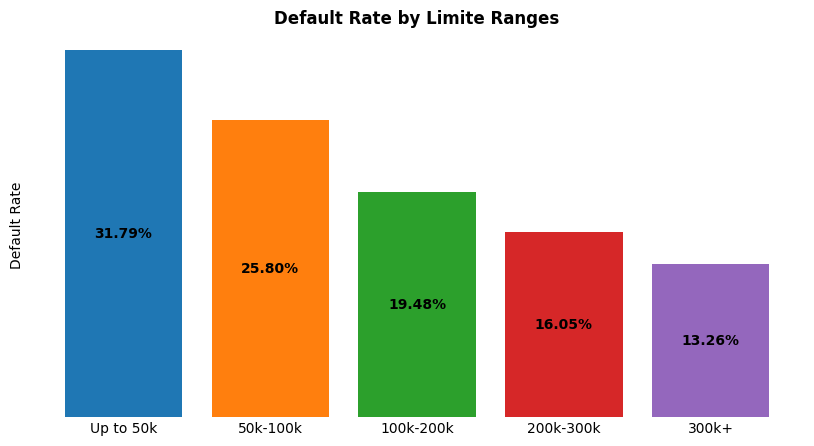

In [35]:
fig, ax = plt.subplots(figsize=(10,5))

ax.bar(default_limit.index, default_limit.values, color=plt.rcParams['axes.prop_cycle'].by_key()['color'])
plt.ylabel('Default Rate')
plt.title('Default Rate by Limite Ranges', fontweight='bold')
plt.bar_label(ax.containers[0], fmt='%.2f%%', label_type='center', fontweight='bold')
plt.tick_params(axis='x', length=0)
plt.yticks([])
plt.box(False)
plt.grid(False)

plt.savefig('default_by_limit.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

O default tende a ser maior quanto menor for o limite. O que faz sentido, já que não se costuma dar limites altos a potenciais devedores. Já aqueles possuem mais credibilidade e confiança do banco tendem a receberem limites maiores.

# **Análise de faturas atrasadas (PAY_)**

In [36]:
pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

df['NUM_DELAYS'] = (df[pay_cols] > 0).sum(axis=1)
df.head(15)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,AGE_GROUP,LIMIT_GROUP,NUM_DELAYS
0,1,20000,2,University,1,24,2,2,-1,-1,...,0,689,0,0,0,0,1,18-25,Up to 50k,2
1,2,120000,2,University,2,26,-1,2,0,0,...,0,1000,1000,1000,0,2000,1,26-35,100k-200k,2
2,3,90000,2,University,2,34,0,0,0,0,...,1518,1500,1000,1000,1000,5000,0,26-35,50k-100k,0
3,4,50000,2,University,1,37,0,0,0,0,...,2000,2019,1200,1100,1069,1000,0,36-50,Up to 50k,0
4,5,50000,1,University,1,57,-1,0,-1,0,...,2000,36681,10000,9000,689,679,0,51+,Up to 50k,0
5,6,50000,1,Graduate School,2,37,0,0,0,0,...,2500,1815,657,1000,1000,800,0,36-50,Up to 50k,0
6,7,500000,1,Graduate School,2,29,0,0,0,0,...,55000,40000,38000,20239,13750,13770,0,26-35,300k+,0
7,8,100000,2,University,2,23,0,-1,-1,0,...,380,601,0,581,1687,1542,0,18-25,50k-100k,0
8,9,140000,2,High School,1,28,0,0,2,0,...,3329,0,432,1000,1000,1000,0,26-35,100k-200k,1
9,10,20000,1,High School,2,35,-2,-2,-2,-2,...,0,0,0,13007,1122,0,0,26-35,Up to 50k,0


In [37]:
default_delay_payments = df.groupby('NUM_DELAYS')['default.payment.next.month'].mean().round(4) * 100
display(default_delay_payments)

,default.payment.next.month
NUM_DELAYS,
0,11.71
1,29.82
2,38.76
3,50.87
4,57.31
5,57.38
6,70.32


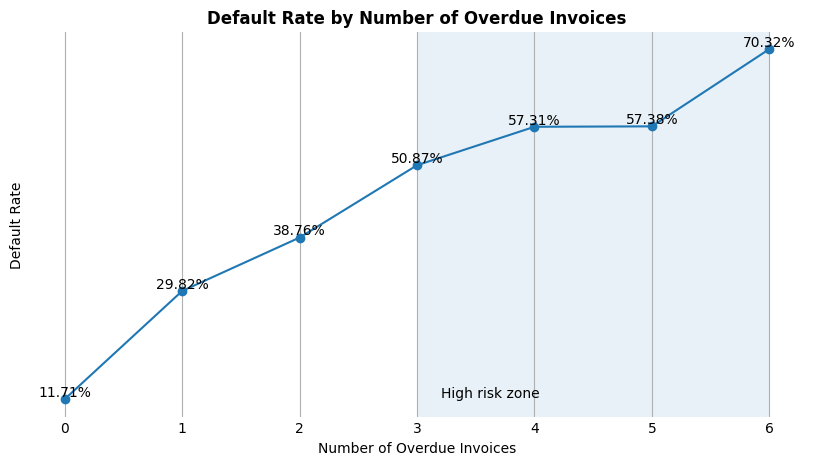

In [38]:
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(default_delay_payments.index, default_delay_payments.values, marker='o')
plt.ylabel('Default Rate')
plt.xlabel('Number of Overdue Invoices')
plt.title('Default Rate by Number of Overdue Invoices', fontweight='bold')

plt.tick_params(axis='x', length=0)
plt.yticks([])
plt.box(False)
plt.grid(True)

for x, y in zip(default_delay_payments.index, default_delay_payments.values):
    ax.text(x, y, f'{y:.2f}%', ha='center', va='bottom')

ax.axvspan(3, max(default_delay_payments.index),alpha=0.1)

ax.text(3.2, 0.05, 'High risk zone', transform=ax.get_xaxis_transform(), fontsize=10)

plt.savefig('default_by_delay_payments.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

Pode-se perceber que quanto mais meses de atraso no pagamento, as chances do cliente ser inadimplente explodem. Esse é o fator mais importante gritante nessa análise.

# **Análise da taxa de utilização do limite do cartão (SOMA(BILL)/LIMIT_BAL)**

In [39]:
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
df['MEAN_BILLS'] = df[bill_cols].mean(axis=1)
df['MEAN_UTILIZATION'] = (df['MEAN_BILLS'] / df['LIMIT_BAL'])
df = df[df['LIMIT_BAL'] > 0]
df.head(20)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,AGE_GROUP,LIMIT_GROUP,NUM_DELAYS,MEAN_BILLS,MEAN_UTILIZATION
0,1,20000,2,University,1,24,2,2,-1,-1,...,0,0,0,0,1,18-25,Up to 50k,2,1284.000000,0.064200
1,2,120000,2,University,2,26,-1,2,0,0,...,1000,1000,0,2000,1,26-35,100k-200k,2,2846.166667,0.023718
2,3,90000,2,University,2,34,0,0,0,0,...,1000,1000,1000,5000,0,26-35,50k-100k,0,16942.166667,0.188246
3,4,50000,2,University,1,37,0,0,0,0,...,1200,1100,1069,1000,0,36-50,Up to 50k,0,38555.666667,0.771113
4,5,50000,1,University,1,57,-1,0,-1,0,...,10000,9000,689,679,0,51+,Up to 50k,0,18223.166667,0.364463
5,6,50000,1,Graduate School,2,37,0,0,0,0,...,657,1000,1000,800,0,36-50,Up to 50k,0,39685.666667,0.793713
6,7,500000,1,Graduate School,2,29,0,0,0,0,...,38000,20239,13750,13770,0,26-35,300k+,0,454099.166667,0.908198
7,8,100000,2,University,2,23,0,-1,-1,0,...,0,581,1687,1542,0,18-25,50k-100k,0,2247.666667,0.022477
8,9,140000,2,High School,1,28,0,0,2,0,...,432,1000,1000,1000,0,26-35,100k-200k,1,10868.666667,0.077633
9,10,20000,1,High School,2,35,-2,-2,-2,-2,...,0,13007,1122,0,0,26-35,Up to 50k,0,4486.500000,0.224325


In [40]:
df['MEAN_UTILIZATION'].describe()

,MEAN_UTILIZATION
count,30000.000000
mean,0.373048
std,0.351890
min,-0.232590
25%,0.029997
50%,0.284834
75%,0.687929
max,5.364308


In [41]:
utilization_bins = [0, 0.3, 0.6, 0.9, float('inf')]
utilization_labels = ['0-30%', '30-60%', '60-90%', '>90%']

df['UTILIZATION_GROUP'] = pd.cut(df['MEAN_UTILIZATION'], bins=utilization_bins, labels=utilization_labels)
df.head(15)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,AGE_GROUP,LIMIT_GROUP,NUM_DELAYS,MEAN_BILLS,MEAN_UTILIZATION,UTILIZATION_GROUP
0,1,20000,2,University,1,24,2,2,-1,-1,...,0,0,0,1,18-25,Up to 50k,2,1284.000000,0.064200,0-30%
1,2,120000,2,University,2,26,-1,2,0,0,...,1000,0,2000,1,26-35,100k-200k,2,2846.166667,0.023718,0-30%
2,3,90000,2,University,2,34,0,0,0,0,...,1000,1000,5000,0,26-35,50k-100k,0,16942.166667,0.188246,0-30%
3,4,50000,2,University,1,37,0,0,0,0,...,1100,1069,1000,0,36-50,Up to 50k,0,38555.666667,0.771113,60-90%
4,5,50000,1,University,1,57,-1,0,-1,0,...,9000,689,679,0,51+,Up to 50k,0,18223.166667,0.364463,30-60%
5,6,50000,1,Graduate School,2,37,0,0,0,0,...,1000,1000,800,0,36-50,Up to 50k,0,39685.666667,0.793713,60-90%
6,7,500000,1,Graduate School,2,29,0,0,0,0,...,20239,13750,13770,0,26-35,300k+,0,454099.166667,0.908198,>90%
7,8,100000,2,University,2,23,0,-1,-1,0,...,581,1687,1542,0,18-25,50k-100k,0,2247.666667,0.022477,0-30%
8,9,140000,2,High School,1,28,0,0,2,0,...,1000,1000,1000,0,26-35,100k-200k,1,10868.666667,0.077633,0-30%
9,10,20000,1,High School,2,35,-2,-2,-2,-2,...,13007,1122,0,0,26-35,Up to 50k,0,4486.500000,0.224325,0-30%


In [42]:
default_by_mean_utilization_limit = df.groupby('UTILIZATION_GROUP')['default.payment.next.month'].mean().round(4) * 100
display(default_by_mean_utilization_limit)

/tmp/ipykernel_4098/1050471090.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_mean_utilization_limit = df.groupby('UTILIZATION_GROUP')['default.payment.next.month'].mean().round(4) * 100


,default.payment.next.month
UTILIZATION_GROUP,
0-30%,16.65
30-60%,21.97
60-90%,27.69
>90%,32.62


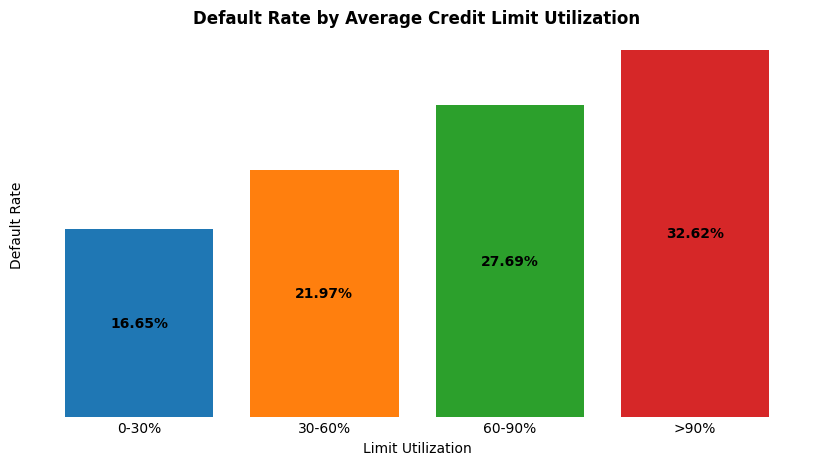

In [43]:
fig, ax = plt.subplots(figsize=(10,5))

ax.bar(default_by_mean_utilization_limit.index, default_by_mean_utilization_limit.values, color=plt.rcParams['axes.prop_cycle'].by_key()['color'])
plt.xlabel('Limit Utilization')
plt.ylabel('Default Rate')
plt.title('Default Rate by Average Credit Limit Utilization', fontweight='bold')
plt.bar_label(ax.containers[0], fmt='%.2f%%', label_type='center', fontweight='bold')
plt.tick_params(axis='x', length=0)
plt.yticks([])
plt.box(False)
plt.grid(False)


plt.savefig('default_by_utilization_limit.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

Quanto maior a taxa de utilização do limite de crédito, maior a chance do cliente ficar inadimplente.

# **Análise taxa de pagamento (Soma(PAY)/Soma(BILL))**

In [44]:
payAMT_cols = ['PAY_AMT1','PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
df['TOTAL_PAYMENTS'] = df[payAMT_cols].sum(axis=1)
df['TOTAL_BILLS'] = df[bill_cols].sum(axis=1)
df['PAYMENT_RATIO'] = (df['TOTAL_PAYMENTS'] / df['TOTAL_BILLS'])

rate_payment_bins = [0, 0.025, 0.05, 0.1, 0.15, 0.2, 0.5, 0.8, float('inf')]
rate_payment_labels = ['0-2.5%', '2.5-5%', '5-10%', '10-15%', '15-20%', '20-50%', '50-80%', '>80']

df['PAYMENT_GROUP'] = pd.cut(df['PAYMENT_RATIO'], bins=rate_payment_bins, labels=rate_payment_labels)
df.head(15)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,AGE_GROUP,LIMIT_GROUP,NUM_DELAYS,MEAN_BILLS,MEAN_UTILIZATION,UTILIZATION_GROUP,TOTAL_PAYMENTS,TOTAL_BILLS,PAYMENT_RATIO,PAYMENT_GROUP
0,1,20000,2,University,1,24,2,2,-1,-1,...,18-25,Up to 50k,2,1284.000000,0.064200,0-30%,689,7704,0.089434,5-10%
1,2,120000,2,University,2,26,-1,2,0,0,...,26-35,100k-200k,2,2846.166667,0.023718,0-30%,5000,17077,0.292791,20-50%
2,3,90000,2,University,2,34,0,0,0,0,...,26-35,50k-100k,0,16942.166667,0.188246,0-30%,11018,101653,0.108388,10-15%
3,4,50000,2,University,1,37,0,0,0,0,...,36-50,Up to 50k,0,38555.666667,0.771113,60-90%,8388,231334,0.036259,2.5-5%
4,5,50000,1,University,1,57,-1,0,-1,0,...,51+,Up to 50k,0,18223.166667,0.364463,30-60%,59049,109339,0.540054,50-80%
5,6,50000,1,Graduate School,2,37,0,0,0,0,...,36-50,Up to 50k,0,39685.666667,0.793713,60-90%,7772,238114,0.032640,2.5-5%
6,7,500000,1,Graduate School,2,29,0,0,0,0,...,26-35,300k+,0,454099.166667,0.908198,>90%,180759,2724595,0.066343,5-10%
7,8,100000,2,University,2,23,0,-1,-1,0,...,18-25,50k-100k,0,2247.666667,0.022477,0-30%,4791,13486,0.355257,20-50%
8,9,140000,2,High School,1,28,0,0,2,0,...,26-35,100k-200k,1,10868.666667,0.077633,0-30%,6761,65212,0.103677,10-15%
9,10,20000,1,High School,2,35,-2,-2,-2,-2,...,26-35,Up to 50k,0,4486.500000,0.224325,0-30%,14129,26919,0.524871,50-80%


In [45]:
default_rate_payment = df.groupby('PAYMENT_GROUP')['default.payment.next.month'].mean().round(4) * 100;
display(default_rate_payment);

/tmp/ipykernel_4098/450627271.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_rate_payment = df.groupby('PAYMENT_GROUP')['default.payment.next.month'].mean().round(4) * 100;


,default.payment.next.month
PAYMENT_GROUP,
0-2.5%,42.05
2.5-5%,25.69
5-10%,26.57
10-15%,21.79
15-20%,18.03
20-50%,15.42
50-80%,15.32
>80,15.19


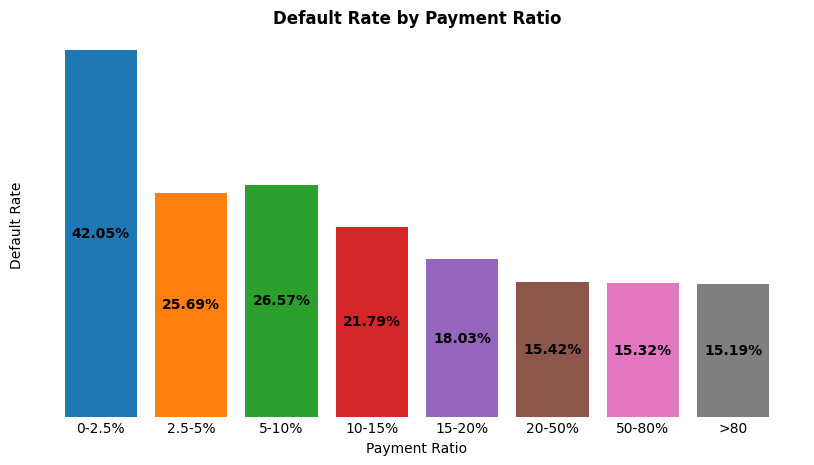

In [46]:
fig, ax = plt.subplots(figsize=(10,5))

ax.bar(default_rate_payment.index, default_rate_payment.values, color=plt.rcParams['axes.prop_cycle'].by_key()['color'])
plt.xlabel('Payment Ratio')
plt.ylabel('Default Rate')
plt.title('Default Rate by Payment Ratio', fontweight='bold')
plt.bar_label(ax.containers[0], fmt='%.2f%%', label_type='center', fontweight='bold')
plt.tick_params(axis='x', length=0)
plt.yticks([])
plt.box(False)
plt.grid(False)


plt.savefig('default_by_payment_ratio.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

Clientes que não pagam ou pagam até 20% da sua dívida tendem a ser muito mais inadimplentes. Como estamos avaliando isso de forma global, ou seja, a taxa de pagamento dos últimos 6 meses, podemos inferir que essa nálise reforça a hipótese de que o atraso no pagamento das faturas é um fator de peso, já que pode-se perceber que a taxa de inadimplência explode conforme a taxa de pagamento tende a zero. Com isso, reforçamos que um mau pagador tende a continuar sendo um mau pagador.

Podemos perceber que as três varáveis que mais tem peso na inadimplência nesse dataset são: números de faturas atrasadas, o limite do cartão e quanto a pessoa utiliza desse limite. Com escolaridade, sexo, idade, estado civil sendo menos significativas, variando em média 5% entre as sua respectivas classificações.

Com isso, podemos inferir que o que realmente importa para análise de default é o histórico financeiro do cliente.

Uma outra análise importante é o First Payment Default (FPD): Refere-se especificamente ao não pagamento da primeira parcela de um financiamento ou compra, um forte indício de fraude ou erro na análise de crédito.

Como não temos esse dado no dataset, vamos então analisar o pagamento em abril, PAY_6, e avaliar se as pessoas que atrasaram esse primeiro pagamento tendem a continuar sendo inadimplentes, fazendo assim uma Lagged Delinquency Analysis.

In [47]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,AGE_GROUP,LIMIT_GROUP,NUM_DELAYS,MEAN_BILLS,MEAN_UTILIZATION,UTILIZATION_GROUP,TOTAL_PAYMENTS,TOTAL_BILLS,PAYMENT_RATIO,PAYMENT_GROUP
0,1,20000,2,University,1,24,2,2,-1,-1,...,18-25,Up to 50k,2,1284.000000,0.064200,0-30%,689,7704,0.089434,5-10%
1,2,120000,2,University,2,26,-1,2,0,0,...,26-35,100k-200k,2,2846.166667,0.023718,0-30%,5000,17077,0.292791,20-50%
2,3,90000,2,University,2,34,0,0,0,0,...,26-35,50k-100k,0,16942.166667,0.188246,0-30%,11018,101653,0.108388,10-15%
3,4,50000,2,University,1,37,0,0,0,0,...,36-50,Up to 50k,0,38555.666667,0.771113,60-90%,8388,231334,0.036259,2.5-5%
4,5,50000,1,University,1,57,-1,0,-1,0,...,51+,Up to 50k,0,18223.166667,0.364463,30-60%,59049,109339,0.540054,50-80%


In [48]:
pay6_labels = {
    -2: 'Pay duly',
    -1: 'Pay duly',
    0: 'Pay duly',
    1: 'Late pay',
    2: 'Late pay',
    3: 'Late pay',
    4: 'Late pay',
    5: 'Late pay',
    6: 'Late pay',
    7: 'Late pay',
    8: 'Late pay',
    9: 'Late pay'
}

In [49]:
FPD_default = df.groupby('PAY_6')['default.payment.next.month'].mean().round(4) * 100
FPD_default = FPD_default.groupby(FPD_default.index.map(pay6_labels)).mean()
display(FPD_default)



,default.payment.next.month
PAY_6,
Late pay,69.741429
Pay duly,18.623333


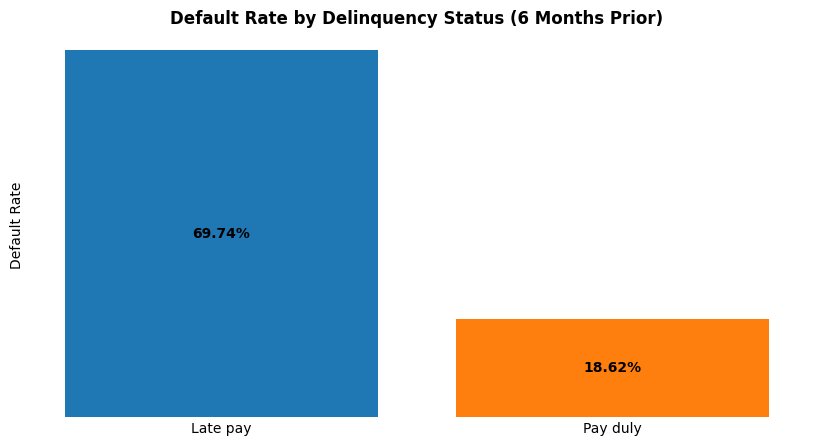

In [50]:
fig, ax = plt.subplots(figsize=(10,5))

ax.bar(FPD_default.index, FPD_default.values, color=plt.rcParams['axes.prop_cycle'].by_key()['color'])
plt.ylabel('Default Rate')
plt.title('Default Rate by Delinquency Status (6 Months Prior)', fontweight='bold')
plt.bar_label(ax.containers[0], fmt='%.2f%%', label_type='center', fontweight='bold')
plt.tick_params(axis='x', length=0)
plt.yticks([])
plt.box(False)
plt.grid(False)

plt.savefig('default_by_PAY6.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

Clientes com histórico de atraso (6 meses atrás) apresentam probabilidade de default quase 4x maior do que aqueles sem atraso.

In [51]:
pay0_labels = {
    -2: 'Pay duly',
    -1: 'Pay duly',
    0: 'Pay duly',
    1: 'Late pay',
    2: 'Late pay',
    3: 'Late pay',
    4: 'Late pay',
    5: 'Late pay',
    6: 'Late pay',
    7: 'Late pay',
    8: 'Late pay',
    9: 'Late pay'
}

In [52]:
P0_default = df.groupby('PAY_0')['default.payment.next.month'].mean().round(4) * 100
P0_default = P0_default.groupby(P0_default.index.map(pay0_labels)).mean()
display(P0_default)


,default.payment.next.month
PAY_0,
Late pay,60.938750
Pay duly,14.273333


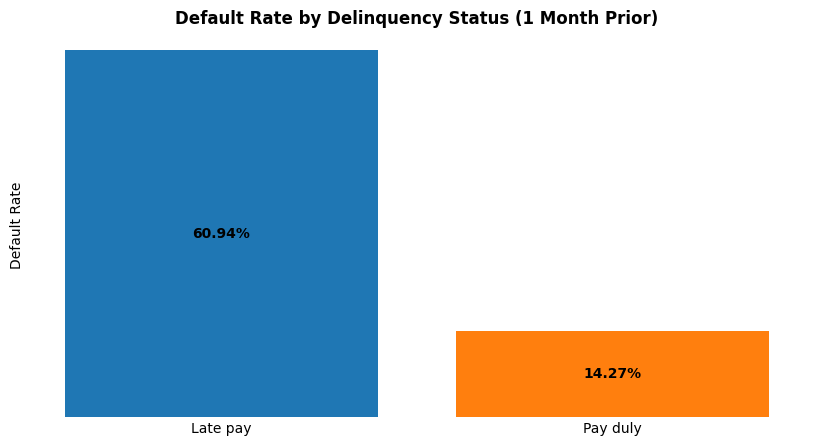

In [53]:
fig, ax = plt.subplots(figsize=(10,5))

ax.bar(P0_default.index, P0_default.values, color=plt.rcParams['axes.prop_cycle'].by_key()['color'])
plt.ylabel('Default Rate')
plt.title('Default Rate by Delinquency Status (1 Month Prior)', fontweight='bold')
plt.bar_label(ax.containers[0], fmt='%.2f%%', label_type='center', fontweight='bold')
plt.tick_params(axis='x', length=0)
plt.yticks([])
plt.box(False)
plt.grid(False)

plt.savefig('default_by_PAY0.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()


---
#Gráfico de correlação entre LIMIT_BAL, NUM_DELAYS, MEAN_UTILIZATION

---



In [54]:
from itertools import combinations

var = ['LIMIT_BAL', 'NUM_DELAYS', 'MEAN_UTILIZATION']


In [55]:
df[var].corr().style.format(precision=2).background_gradient(cmap='coolwarm_r', vmin=-1, vmax=1)

,LIMIT_BAL,NUM_DELAYS,MEAN_UTILIZATION
LIMIT_BAL,1.00,-0.24,-0.38
NUM_DELAYS,-0.24,1.00,0.23
MEAN_UTILIZATION,-0.38,0.23,1.00


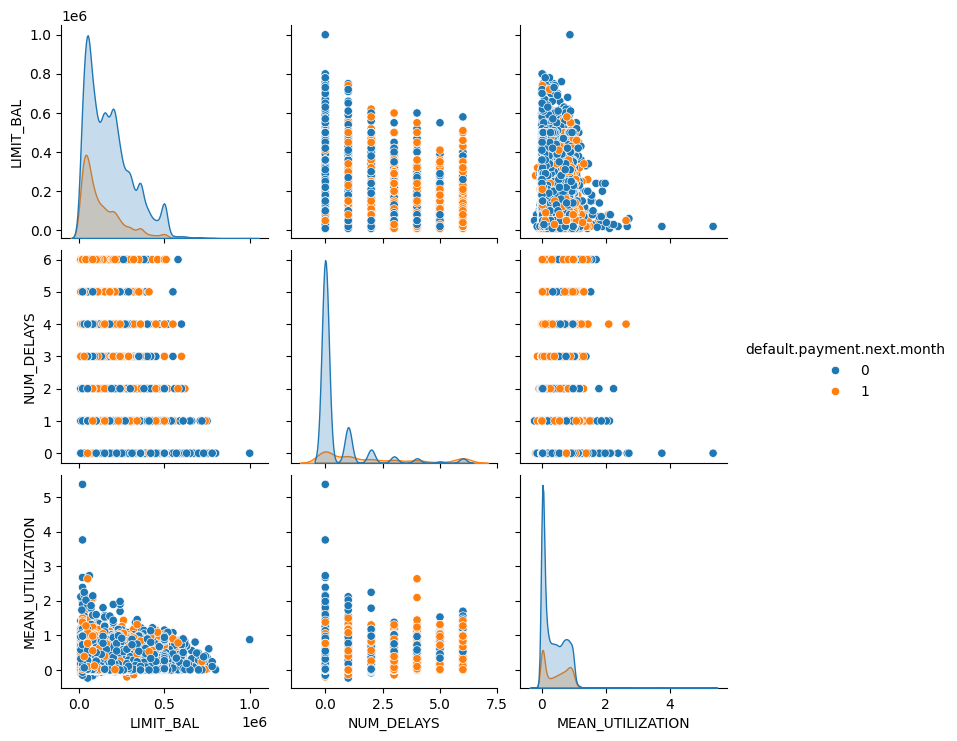

In [56]:
import seaborn as sns

sns.pairplot(df[var + ['default.payment.next.month']],
             hue='default.payment.next.month')